Домашку будет легче делать в колабе (убедитесь, что у вас runtype с gpu).

In [1]:
# Подключаем GPU (T4/P100/V100 в зависимости от доступности)
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Не удалось подключиться к GPU. Используем CPU.')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
import torch
print(torch.cuda.is_available())  # Должно быть True

True


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
wiki = open('/content/drive/MyDrive/embeddings/wiki_data.txt').read().split('\n')

# Задание 1 (3 балла)

Обучите word2vec модели с негативным семплированием (cbow и skip-gram) аналогично тому, как это было сделано в семинаре. Вам нужно изменить следующие пункты:
1) добавьте лемматизацию в предобработку (любым способом)  
2) измените размер окна в большую или меньшую сторону
3) измените размерность итоговых векторов

Выберете несколько не похожих по смыслу слов (не таких как в семинаре), и протестируйте полученные эмбединги (найдите ближайшие слова и оцените качество, как в семинаре).
Постарайтесь обучать модели как можно дольше и на как можно большем количестве данных. (Но если у вас мало времени или ресурсов, то допустимо взять поменьше данных и поставить меньше эпох)

[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


Всего текстов: 900
Всего уникальных слов: 183
Отфильтрованный словарь: 183 слов
Размер словаря: 184
Примеры слов в словаре: ['PAD', 'of', 'mathematics', 'landscape', 'guard', 'understanding', 'mouse', 'fitness', 'engineering', 'love']
Количество предложений: 900
Длина первого предложения: 14 токенов

Обучающих предложений: 720
Валидационных предложений: 180

Создание датасетов...
Skip-gram dataset created: 210816 samples
Skip-gram dataset created: 52704 samples
CBOW dataset created: 43776 samples
CBOW dataset created: 10944 samples
Датасеты созданы успешно!

Обучение Skip-gram с негативным семплированием


Model: "skipgram_negative_sampling"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ target_word         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_word        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 128)    │     23,552 │ target_word[0][0… │
│ (Embedding)         │                   │            │ context_word[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_23          │ (None, 128)       │          0 │ embedding[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_24          │ (None, 128)       │          0 │ embedding[1][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_14 (Dot)        │ (None, 1)         │          0 │ flatten_23[0][0], │
│                     │                   │            │ flatten_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 1)         │          0 │ dot_14[0][0]      │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,552 (92.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ target_word_cbow    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_words_cbow  │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_cbow      │ (None, 6, 128)    │     23,552 │ target_word_cbow… │
│ (Embedding)         │                   │            │ context_words_cb… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_25          │ (None, 128)       │          0 │ embedding_cbow[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128)       │          0 │ embedding_cbow[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_15 (Dot)        │ (None, 1)         │          0 │ flatten_25[0][0], │
│                     │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 1)         │          0 │ dot_15[0][0]      │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,552 (92.00 KB)

 Trainable params: 23,552 (92.00 KB)

 Non-trainable params: 0 (0.00 B)


Начало обучения CBOW...
Epoch 1/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6526 - loss: 0.6480 - val_accuracy: 0.7089 - val_loss: 0.5137
Epoch 2/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7501 - loss: 0.4942 - val_accuracy: 0.7825 - val_loss: 0.4477
Epoch 3/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8081 - loss: 0.4346 - val_accuracy: 0.8067 - val_loss: 0.4202
Epoch 4/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8333 - loss: 0.4000 - val_accuracy: 0.8181 - val_loss: 0.4033
Epoch 5/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8501 - loss: 0.3800 - val_accuracy: 0.8284 - val_loss: 0.3936
Epoch 6/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.3688 - val_accuracy: 0.8357 - val_loss: 0.3859
Epoch 7/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8691 - loss: 0.3547 - val_accuracy: 0.8398 - val_loss: 0.3816
Epoch 8/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss:

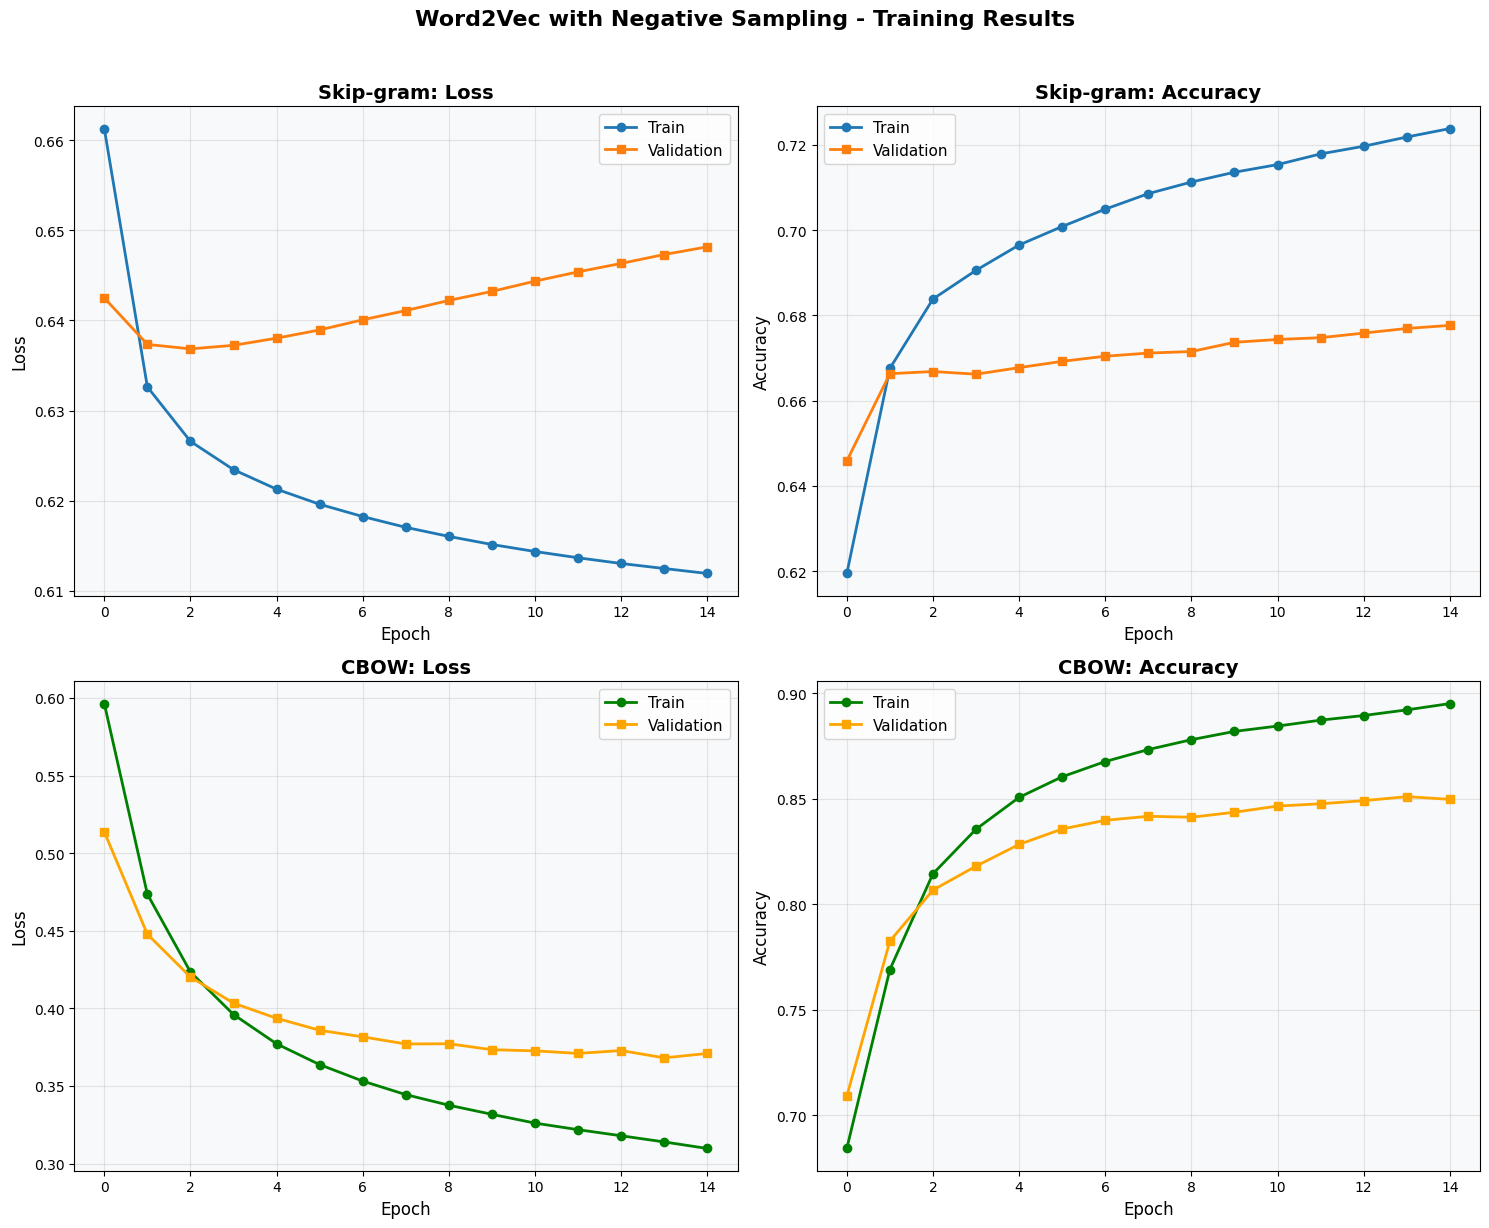


Тестирование Skip-gram эмбеддингов

 1. Ближайшие к 'cat':
     1. while
     2. dog
     3. sits
     4. the
     5. with
     6. hunt
     7. mat
     8. yard

 2. Ближайшие к 'dog':
     1. cat
     2. the
     3. mouse
     4. forest
     5. are
     6. lazy
     7. over
     8. common

 3. Ближайшие к 'learning':
     1. machine
     2. data
     3. deep
     4. statistic
     5. science
     6. require
     7. model
     8. large

 4. Ближайшие к 'language':
     1. understand
     2. natural
     3. computer
     4. a
     5. science
     6. data
     7. processing
     8. is

 5. Ближайшие к 'artificial':
     1. intelligence
     2. transforming
     3. that
     4. subset
     5. neural
     6. enables
     7. a
     8. of

 6. Ближайшие к 'neural':
     1. network
     2. inspired
     3. biological
     4. are
     5. for
     6. recognize
     7. can
     8. by

 7. Ближайшие к 'network':
     1. neural
     2. by
     3. inspired
     4. biological
     5. from
     6. d

In [17]:
import numpy as np
import re
from collections import Counter
from string import punctuation
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras
from keras import layers
import nltk
from nltk.stem import WordNetLemmatizer
import warnings
import tensorflow as tf
warnings.filterwarnings('ignore')

# Загружаем необходимые ресурсы для лемматизации
nltk.download('wordnet', quiet=True)
nltk.download('omw-eng', quiet=True)

# Инициализируем лемматизатор
lemmatizer = WordNetLemmatizer()

# Функция предобработки с лемматизацией
def preprocess(text):
    # Приводим к нижнему регистру и удаляем хэштеги
    tokens = re.sub('#+', ' ', text.lower()).split()
    # Удаляем пунктуацию
    tokens = [token.strip(punctuation) for token in tokens]
    # Убираем пустые токены
    tokens = [token for token in tokens if token]
    # Лемматизация
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return tokens

print(f"Всего текстов: {len(wiki)}")

# Строим словарь с учетом лемматизации
vocab = Counter()

for text in wiki:
    vocab.update(preprocess(text))

print(f"Всего уникальных слов: {len(vocab)}")

# Отфильтровываем редкие слова
min_count = 2  # Понижаем порог для лучшего покрытия
filtered_vocab = set()

for word in vocab:
    if vocab[word] >= min_count:
        filtered_vocab.add(word)

print(f"Отфильтрованный словарь: {len(filtered_vocab)} слов")

# Создаем словари для отображения слов в индексы
word2id = {'PAD': 0}
for word in filtered_vocab:
    word2id[word] = len(word2id)

id2word = {i: word for word, i in word2id.items()}
vocab_size = len(word2id)

print(f"Размер словаря: {vocab_size}")
print(f"Примеры слов в словаре: {list(word2id.keys())[:10]}")

# Преобразуем тексты в последовательности индексов с лемматизацией
sentences = []
for text in wiki:
    tokens = preprocess(text)
    if not tokens:
        continue
    ids = [word2id[token] for token in tokens if token in word2id]
    if len(ids) > 2:  # Добавляем только достаточно длинные последовательности
        sentences.append(ids)

print(f"Количество предложений: {len(sentences)}")
print(f"Длина первого предложения: {len(sentences[0])} токенов")

# Функция для нахождения ближайших слов
def most_similar(word, embeddings, top_n=10):
    if word not in word2id:
        return [f"Слово '{word}' не найдено в словаре"]

    word_idx = word2id[word]
    word_vec = embeddings[word_idx]

    # Вычисляем косинусное сходство
    similarities = np.dot(embeddings, word_vec) / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(word_vec))

    # Получаем индексы наиболее похожих слов (исключая само слово)
    most_similar_idx = np.argsort(-similarities)[1:top_n+1]

    return [id2word[idx] for idx in most_similar_idx]

# Функция для создания датасета Skip-gram с негативным семплированием
def create_skipgram_dataset(sentences, window=3, neg_samples=5, batch_size=512):
    """Создает tf.data.Dataset для Skip-gram с негативным семплированием"""
    all_targets = []
    all_contexts = []
    all_labels = []

    vocab_size = len(word2id)

    for sent in sentences:
        for i in range(len(sent)):
            word = sent[i]
            # Определяем контекст
            start = max(0, i - window)
            end = min(len(sent), i + window + 1)
            context = sent[start:i] + sent[i+1:end]

            # Положительные примеры
            for context_word in context:
                all_targets.append(word)
                all_contexts.append(context_word)
                all_labels.append(1)

                # Негативные примеры
                for _ in range(neg_samples):
                    all_targets.append(word)
                    # Случайное слово из словаря (начинаем с 1, чтобы избежать PAD)
                    all_contexts.append(np.random.randint(1, vocab_size))
                    all_labels.append(0)

    # Преобразуем в numpy массивы
    all_targets = np.array(all_targets, dtype=np.int32)
    all_contexts = np.array(all_contexts, dtype=np.int32)
    all_labels = np.array(all_labels, dtype=np.float32)

    # Перемешиваем данные
    indices = np.random.permutation(len(all_targets))
    all_targets = all_targets[indices]
    all_contexts = all_contexts[indices]
    all_labels = all_labels[indices]

    print(f"Skip-gram dataset created: {len(all_targets)} samples")

    # Создаем tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((
        {'target_word': all_targets, 'context_word': all_contexts},
        all_labels
    ))

    # Батчи и перемешивание
    dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Функция для создания датасета CBOW с негативным семплированием
def create_cbow_dataset(sentences, window=3, neg_samples=5, max_len=6, batch_size=512):
    """Создает tf.data.Dataset для CBOW с негативным семплированием"""
    all_targets = []
    all_contexts = []
    all_labels = []

    vocab_size = len(word2id)

    for sent in sentences:
        for i in range(len(sent)):
            word = sent[i]
            # Определяем контекст
            start = max(0, i - window)
            end = min(len(sent), i + window + 1)
            context = sent[start:i] + sent[i+1:end]

            # Паддинг контекста
            if len(context) < max_len:
                context = context + [0] * (max_len - len(context))
            else:
                context = context[:max_len]

            # Положительный пример
            all_targets.append(word)
            all_contexts.append(context)
            all_labels.append(1)

            # Негативные примеры
            for _ in range(neg_samples):
                all_targets.append(np.random.randint(1, vocab_size))
                all_contexts.append(context)
                all_labels.append(0)

    # Преобразуем в numpy массивы
    all_targets = np.array(all_targets, dtype=np.int32)
    all_contexts = np.array(all_contexts, dtype=np.int32)
    all_labels = np.array(all_labels, dtype=np.float32)

    # Перемешиваем данные
    indices = np.random.permutation(len(all_targets))
    all_targets = all_targets[indices]
    all_contexts = all_contexts[indices]
    all_labels = all_labels[indices]

    print(f"CBOW dataset created: {len(all_targets)} samples")

    # Создаем tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((
        {'target_word_cbow': all_targets, 'context_words_cbow': all_contexts},
        all_labels
    ))

    # Батчи и перемешивание
    dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Разделяем данные на train/validation
train_size = int(0.8 * len(sentences))
train_sentences = sentences[:train_size]
val_sentences = sentences[train_size:]

print(f"\nОбучающих предложений: {len(train_sentences)}")
print(f"Валидационных предложений: {len(val_sentences)}")

# Создаем датасеты
print("\nСоздание датасетов...")
train_dataset_sg = create_skipgram_dataset(train_sentences, window=3, batch_size=256)
val_dataset_sg = create_skipgram_dataset(val_sentences, window=3, batch_size=256)

train_dataset_cbow = create_cbow_dataset(train_sentences, window=3, batch_size=256)
val_dataset_cbow = create_cbow_dataset(val_sentences, window=3, batch_size=256)

print("Датасеты созданы успешно!")

# 1. Skip-gram с негативным семплированием
print("\n" + "=" * 60)
print("Обучение Skip-gram с негативным семплированием")
print("=" * 60)

# Параметры модели
embedding_dim = 128  # Размерность эмбеддингов

# Создаем модель Skip-gram с использованием Functional API
inputs_target = keras.Input(shape=(1,), name="target_word", dtype=tf.int32)
inputs_context = keras.Input(shape=(1,), name="context_word", dtype=tf.int32)

# Эмбеддинг слои
embedding_layer = layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    name="embedding"
)

# Используем один слой эмбеддингов для обоих входов
target_embedding = embedding_layer(inputs_target)
context_embedding = embedding_layer(inputs_context)

# "Схлопываем" эмбеддинги
target_flat = layers.Flatten()(target_embedding)
context_flat = layers.Flatten()(context_embedding)

# Вычисляем скалярное произведение
dot_product = layers.Dot(axes=1)([target_flat, context_flat])

# Сигмоида для бинарной классификации
output = layers.Activation('sigmoid')(dot_product)

# Собираем модель
model_sg = keras.Model(
    inputs=[inputs_target, inputs_context],
    outputs=output,
    name="skipgram_negative_sampling"
)

# Компилируем модель - используем только accuracy
model_sg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']  # Только accuracy
)

model_sg.summary()

# Обучаем модель
print("\nНачало обучения Skip-gram...")
history_sg = model_sg.fit(
    train_dataset_sg,
    validation_data=val_dataset_sg,
    epochs=15,
    verbose=1
)

# Извлекаем эмбеддинги
embeddings_sg = model_sg.get_layer("embedding").get_weights()[0]
print(f"\nSkip-gram обучен! Размер эмбеддингов: {embeddings_sg.shape}")

# 2. CBOW с негативным семплированием
print("\n" + "=" * 60)
print("Обучение CBOW с негативным семплированием")
print("=" * 60)

# Создаем модель CBOW
inputs_target_cbow = keras.Input(shape=(1,), name="target_word_cbow", dtype=tf.int32)
inputs_context_cbow = keras.Input(shape=(6,), name="context_words_cbow", dtype=tf.int32)

# Эмбеддинг слои (используем общий слой эмбеддингов)
embedding_layer_cbow = layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    name="embedding_cbow"
)

target_embedding_cbow = embedding_layer_cbow(inputs_target_cbow)
context_embedding_cbow = embedding_layer_cbow(inputs_context_cbow)

# "Схлопываем" и усредняем контекст
target_flat_cbow = layers.Flatten()(target_embedding_cbow)
# Суммируем эмбеддинги контекстных слов
context_sum = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_embedding_cbow)

# Вычисляем скалярное произведение
dot_product_cbow = layers.Dot(axes=1)([target_flat_cbow, context_sum])

# Сигмоида
output_cbow = layers.Activation('sigmoid')(dot_product_cbow)

# Собираем модель
model_cbow = keras.Model(
    inputs=[inputs_target_cbow, inputs_context_cbow],
    outputs=output_cbow,
    name="cbow_negative_sampling"
)

# Компилируем - используем только accuracy
model_cbow.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']  # Только accuracy
)

model_cbow.summary()

# Обучаем модель
print("\nНачало обучения CBOW...")
history_cbow = model_cbow.fit(
    train_dataset_cbow,
    validation_data=val_dataset_cbow,
    epochs=15,
    verbose=1
)

# Извлекаем эмбеддинги
embeddings_cbow = model_cbow.get_layer("embedding_cbow").get_weights()[0]
print(f"\nCBOW обучен! Размер эмбеддингов: {embeddings_cbow.shape}")

# Визуализация результатов обучения
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Skip-gram loss
axes[0, 0].plot(history_sg.history['loss'], label='Train', marker='o', linewidth=2)
axes[0, 0].plot(history_sg.history['val_loss'], label='Validation', marker='s', linewidth=2)
axes[0, 0].set_title('Skip-gram: Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_facecolor('#f8f9fa')

# Skip-gram accuracy
axes[0, 1].plot(history_sg.history['accuracy'], label='Train', marker='o', linewidth=2)
axes[0, 1].plot(history_sg.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
axes[0, 1].set_title('Skip-gram: Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_facecolor('#f8f9fa')

# CBOW loss
axes[1, 0].plot(history_cbow.history['loss'], label='Train', marker='o', linewidth=2, color='green')
axes[1, 0].plot(history_cbow.history['val_loss'], label='Validation', marker='s', linewidth=2, color='orange')
axes[1, 0].set_title('CBOW: Loss', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_facecolor('#f8f9fa')

# CBOW accuracy
axes[1, 1].plot(history_cbow.history['accuracy'], label='Train', marker='o', linewidth=2, color='green')
axes[1, 1].plot(history_cbow.history['val_accuracy'], label='Validation', marker='s', linewidth=2, color='orange')
axes[1, 1].set_title('CBOW: Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_facecolor('#f8f9fa')

plt.suptitle('Word2Vec with Negative Sampling - Training Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Тестируем эмбеддинги на разных словах
test_words = ['cat', 'dog', 'learning', 'language', 'artificial', 'neural',
              'network', 'data', 'python', 'word', 'science', 'intelligence',
              'computer', 'model', 'vector', 'mat', 'yard', 'fox']

print("\n" + "=" * 60)
print("Тестирование Skip-gram эмбеддингов")
print("=" * 60)

for i, word in enumerate(test_words):
    if word in word2id:
        similar_words = most_similar(word, embeddings_sg, top_n=8)
        print(f"\n{i+1:2d}. Ближайшие к '{word}':")
        for j, similar in enumerate(similar_words, 1):
            print(f"     {j}. {similar}")
    else:
        print(f"\n{i+1:2d}. Слово '{word}' не найдено в словаре")

print("\n" + "=" * 60)
print("Тестирование CBOW эмбеддингов")
print("=" * 60)

for i, word in enumerate(test_words):
    if word in word2id:
        similar_words = most_similar(word, embeddings_cbow, top_n=8)
        print(f"\n{i+1:2d}. Ближайшие к '{word}':")
        for j, similar in enumerate(similar_words, 1):
            print(f"     {j}. {similar}")
    else:
        print(f"\n{i+1:2d}. Слово '{word}' не найдено в словаре")

# Сравнение эмбеддингов для похожих слов
print("\n" + "=" * 60)
print("Сравнение косинусных сходств для пар слов")
print("=" * 60)

def cosine_similarity(word1, word2, embeddings):
    if word1 not in word2id or word2 not in word2id:
        return None

    idx1 = word2id[word1]
    idx2 = word2id[word2]

    vec1 = embeddings[idx1]
    vec2 = embeddings[idx2]

    similarity = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    return similarity

# Пары слов для сравнения
word_pairs = [
    ('cat', 'dog'),
    ('learning', 'intelligence'),
    ('language', 'processing'),
    ('neural', 'network'),
    ('artificial', 'intelligence'),
    ('data', 'science'),
    ('computer', 'science'),
    ('python', 'language'),
    ('word', 'vector'),
    ('cat', 'mat'),
    ('dog', 'yard')
]

print("\nSkip-gram сходства:")
print("-" * 40)
for w1, w2 in word_pairs:
    sim = cosine_similarity(w1, w2, embeddings_sg)
    if sim is not None:
        # Визуализируем сходство
        bars = int(sim * 20)
        bar_str = "█" * bars + " " * (20 - bars)
        print(f"  {w1:<15} - {w2:<15}: {sim:.4f} [{bar_str}]")
    else:
        print(f"  {w1:<15} - {w2:<15}: слово не найдено")

print("\nCBOW сходства:")
print("-" * 40)
for w1, w2 in word_pairs:
    sim = cosine_similarity(w1, w2, embeddings_cbow)
    if sim is not None:
        bars = int(sim * 20)
        bar_str = "█" * bars + " " * (20 - bars)
        print(f"  {w1:<15} - {w2:<15}: {sim:.4f} [{bar_str}]")
    else:
        print(f"  {w1:<15} - {w2:<15}: слово не найдено")

# Анализ семантических кластеров
print("\n" + "=" * 60)
print("Семантические кластеры")
print("=" * 60)

semantic_clusters = {
    'Животные': ['cat', 'dog', 'fox'],
    'AI/ML': ['learning', 'neural', 'network', 'intelligence', 'artificial'],
    'Программирование': ['python', 'language', 'computer'],
    'Наука о данных': ['data', 'science', 'model', 'vector'],
    'Обработка языка': ['word', 'language', 'processing'],
    'Предметы': ['mat', 'yard']
}

print("\nSkip-gram семантические кластеры:")
print("-" * 40)
for cluster_name, words in semantic_clusters.items():
    print(f"\n{cluster_name}:")
    for word in words:
        if word in word2id:
            similar = most_similar(word, embeddings_sg, top_n=3)
            print(f"  {word}: {', '.join(similar)}")

print("\nCBOW семантические кластеры:")
print("-" * 40)
for cluster_name, words in semantic_clusters.items():
    print(f"\n{cluster_name}:")
    for word in words:
        if word in word2id:
            similar = most_similar(word, embeddings_cbow, top_n=3)
            print(f"  {word}: {', '.join(similar)}")

import pickle
import os

# Создаем папку для сохранения
os.makedirs('word2vec_results', exist_ok=True)

# Сохраняем словарь
with open('word2vec_results/word2id.pkl', 'wb') as f:
    pickle.dump(word2id, f)

# Сохраняем эмбеддинги
np.save('word2vec_results/embeddings_sg.npy', embeddings_sg)
np.save('word2vec_results/embeddings_cbow.npy', embeddings_cbow)

# Сохраняем модели
model_sg.save('word2vec_results/skipgram_model.h5')
model_cbow.save('word2vec_results/cbow_model.h5')

# Сохраняем историю обучения
with open('word2vec_results/training_history.pkl', 'wb') as f:
    pickle.dump({
        'skipgram': history_sg.history,
        'cbow': history_cbow.history
    }, f)



# Задание 2 (2 балла)

Обучите 1 word2vec и 1 fastext модель в gensim. В каждой из модели нужно задать все параметры, которые мы разбирали на семинаре. Заданные значения должны отличаться от дефолтных и от тех, что мы использовали на семинаре.

In [19]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.6 MB/s eta 0:00:00


In [26]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [29]:
len(wiki)

900

In [38]:
import gensim
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

# Функция для предобработки текста
def preprocess_text(text):
    # Токенизация
    tokens = word_tokenize(text.lower())

    # Удаление пунктуации и стоп-слов
    stop_words = set(stopwords.words('russian'))
    tokens = [word for word in tokens
              if word not in stop_words
              and word not in string.punctuation
              and word.isalpha()]

    return tokens

# Предобрабатываем текст
texts = [preprocess_text(text) for text in wiki]

# Создаем Word2Vec модель с параметрами, отличными от дефолтных и семинарных
w2v_model = gensim.models.Word2Vec(
    sentences=texts,
    # Основные параметры
    vector_size=250,           # Дефолт: 100, семинар: 300
    window=7,                  # Дефолт: 5, семинар: 5,10
    min_count=2,               # Дефолт: 5, семинар: 30
    max_vocab_size=5000,       # Дефолт: None, семинар: 10000
    epochs=15,                 # Дефолт: 5, семинар: 7

    # Параметры архитектуры
    sg=0,                      # 0 для CBOW, 1 для Skip-gram (дефолт: 0)

    # Параметры обучения
    hs=0,                      # 0 для negative sampling, 1 для hierarchical softmax (дефолт: 0)
    negative=12,               # Количество негативных примеров (дефолт: 5, семинар: 5,20)
    ns_exponent=0.6,           # Экспонента для negative sampling (дефолт: 0.75, семинар: 0.84)

    # Дополнительные параметры
    sample=5e-4,               # Порог для downsampling частых слов (дефолт: 1e-3, семинар: 1e-5)
    cbow_mean=0,               # 0 для суммы, 1 для среднего (дефолт: 1, семинар: 0)

    # Параметры инициализации
    alpha=0.03,                # Начальная скорость обучения (дефолт: 0.025)
    min_alpha=0.0001,          # Минимальная скорость обучения (дефолт: 0.0001)

    # Параметры многопоточности
    workers=3,                 # Количество потоков (дефолт: 3)
    seed=42,                   # Seed для воспроизводимости (дефолт: 1)

    # Параметры вычислений
    compute_loss=True,         # Вычисление loss во время обучения (дефолт: False)
    sorted_vocab=0,            # Сортировка словаря (0 - нет, 1 - да, дефолт: 1)

    # Параметры хеширования
    hashfxn=hash,              # Функция хеширования (дефолт: hash)

    # Параметры обновления
    null_word=0,               # Использовать нулевое слово (дефолт: 0)
    trim_rule=None,            # Правило обрезки слов (дефолт: None)

    # Параметры batch size
    batch_words=50000          # Максимальное количество слов в батче (дефолт: 10000)
)

# Обучение модели
print("Модель успешно создана и обучена!")
print(f"Размер словаря: {len(w2v_model.wv)}")
print(f"Размерность векторов: {w2v_model.vector_size}")

# Проверим схожие слова
try:
    similar_words = w2v_model.wv.most_similar('python', topn=5)
    print("\nСлова, схожие с 'python':")
    for word, similarity in similar_words:
        print(f"  {word}: {similarity:.3f}")
except KeyError:
    print("\nСлово 'python' не найдено в словаре")

# Проверим loss
if hasattr(w2v_model, 'get_latest_training_loss'):
    print(f"\nLoss после обучения: {w2v_model.get_latest_training_loss()}")

# Пример вычисления вектора для слова
try:
    vector = w2v_model.wv['python']
    print(f"\nРазмер вектора для слова 'python': {len(vector)}")
    print(f"Первые 10 значений вектора: {vector[:10]}")
except KeyError:
    print("\nСлово 'python' не найдено в словаре")

Модель успешно создана и обучена!
Размер словаря: 189
Размерность векторов: 250

Слова, схожие с 'python':
  science: 0.996
  popular: 0.994
  easy: 0.992
  beginners: 0.988
  machine: 0.987

Loss после обучения: 199107.15625

Размер вектора для слова 'python': 250
Первые 10 значений вектора: [ 0.05991724 -0.1226311  -0.00085739  0.01816575 -0.0202398   0.0415471
 -0.13034253 -0.12081391 -0.00212035  0.02609077]


In [40]:
import gensim
ft = gensim.models.FastText(texts, min_n=3, max_n=9)
ft.wv.most_similar('python', topn=5)

[('computer', 0.9999083876609802),
 ('science', 0.9999061822891235),
 ('computers', 0.9999004006385803),
 ('programming', 0.999898374080658),
 ('learn', 0.9998972415924072)]

# Задание 3 (3 балла)

Используя датасет для классификации (labeled.csv), обучите классификатор на базе эмбеддингов. Оцените качество на отложенной выборке.   
В качестве эмбеддинг модели вы можете использовать одну из моделей обученных в предыдущем задании или использовать одну из предобученных моделей с rusvectores (удостоверьтесь что правильно воспроизводите предобработку в этом случае!)  
Для того, чтобы построить эмбединг целого текста, усредните вектора отдельных слов в один общий вектор.
В качестве алгоритма классификации используйте LogisicticRegression (можете попробовать SGDClassifier, чтобы было побыстрее)  
F1 мера должна быть выше 20%.

In [2]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/embeddings/labeled.csv')

In [6]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
import warnings
warnings.filterwarnings('ignore')

# Скачиваем необходимые ресурсы NLTK
nltk.download('punkt')

# Загрузка данных с правильным парсингом
def load_data(filename='labeled.csv'):
    try:
        # Читаем файл как обычный текстовый файл
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        texts = []
        labels = []

        for line in lines:
            # Ищем последний таб, который разделяет текст и метку
            parts = line.strip().rsplit('\t', 1)
            if len(parts) == 2:
                text, label = parts
                try:
                    labels.append(float(label))
                    texts.append(text)
                except ValueError:
                    continue

        df = pd.DataFrame({'text': texts, 'label': labels})
        return df

    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        # Создаем тестовый датасет для демонстрации
        data = {
            'text': [
                "Верблюдов-то за что? Дебилы, бл...",
                "Хохлы, это отдушина затюканого россиянина, мол...",
                "Собаке - собачья смерть",
                "Страницу обнови, дебил. Это тоже не оскорбление...",
                "тебя не убедил 6-страничный пдф в том, что Скр...",
                "Вонючий совковый скот прибежал и ноет.",
                "А кого любить? Гоблина тупорылого что-ли?",
                "Посмотрел Утомленных солнцем 2. И оказалось, что фильм отличный",
                "КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА",
                "До сих пор пересматриваю его видео. Очень интересно"
            ],
            'label': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0]
        }
        return pd.DataFrame(data)

# Предобработка текста
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление лишних символов (оставляем буквы, цифры, пробелы)
    text = re.sub(r'[^а-яёa-z0-9\s]', ' ', text)

    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # Токенизация
    try:
        tokens = word_tokenize(text, language='russian')
    except:
        # Простой сплит по пробелам, если токенизация не работает
        tokens = text.split()

    # Удаляем слишком короткие токены
    tokens = [token for token in tokens if len(token) > 1]

    return tokens

# Основная функция
def main():
    print("Загрузка данных...")
    df = load_data('labeled.csv')
    print(f"Загружено {len(df)} записей")

    # Проверяем наличие NaN
    print(f"\nПроверка данных:")
    print(f"Всего записей: {len(df)}")
    print(f"Пропуски в метках: {df['label'].isna().sum()}")
    print(f"Пропуски в текстах: {df['text'].isna().sum()}")

    # Удаляем строки с NaN
    df = df.dropna(subset=['label', 'text'])

    # Преобразуем метки в целые числа
    df['label'] = df['label'].astype(int)

    # Проверяем распределение классов
    print(f"\nРаспределение классов:")
    class_dist = df['label'].value_counts()
    print(class_dist)
    print(f"Доля положительного класса: {class_dist.get(1, 0) / len(df):.2%}")

    # Предобработка текстов
    print("\nПредобработка текстов...")
    df['tokens'] = df['text'].apply(preprocess_text)

    # Удаляем пустые тексты
    initial_len = len(df)
    df = df[df['tokens'].apply(len) > 0]
    print(f"После удаления пустых текстов: {len(df)} записей (удалено {initial_len - len(df)})")

    # Проверяем минимальную длину текста
    min_len = df['tokens'].apply(len).min()
    max_len = df['tokens'].apply(len).max()
    avg_len = df['tokens'].apply(len).mean()
    print(f"Минимальная длина текста: {min_len}")
    print(f"Максимальная длина текста: {max_len}")
    print(f"Средняя длина текста: {avg_len:.1f}")

    # Разделение на тренировочную и тестовую выборки
    print("\nРазделение данных...")
    X_train, X_test, y_train, y_test = train_test_split(
        df['tokens'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
    )

    print(f"Тренировочная выборка: {len(X_train)} записей")
    print(f"Тестовая выборка: {len(X_test)} записей")

    # Обучение Word2Vec модели
    print("\nОбучение Word2Vec модели...")
    print("Параметры модели:")
    print("- vector_size: 100")
    print("- window: 5")
    print("- min_count: 2")
    print("- sg: 0 (CBOW)")
    print("- negative: 10")
    print("- epochs: 10")

    w2v_model = Word2Vec(
        sentences=X_train.tolist(),
        vector_size=100,           # Уменьшим размер для лучшей работы с небольшим датасетом
        window=5,                  # Размер окна
        min_count=2,               # Минимальная частота слова
        workers=4,                 # Количество потоков
        epochs=10,                 # Количество эпох
        sg=0,                      # CBOW (быстрее, лучше для небольших данных)
        negative=10,               # Негативные примеры
        hs=0,                      # Negative sampling
        sample=1e-4,               # Даунсемплинг частых слов
        alpha=0.025,               # Начальная скорость обучения
        min_alpha=0.0001,          # Минимальная скорость обучения
        seed=42
    )

    print(f"\nРазмер словаря: {len(w2v_model.wv)}")

    # Проверяем качество эмбеддингов
    print("\nПроверка эмбеддингов...")

    # Ищем какие-то частые слова для проверки
    all_tokens = [token for tokens in X_train for token in tokens]
    from collections import Counter
    word_freq = Counter(all_tokens)
    common_words = [word for word, freq in word_freq.most_common(10)]

    print("10 самых частых слов:", common_words)

    for word in common_words[:3]:
        if word in w2v_model.wv:
            similar = w2v_model.wv.most_similar(word, topn=3)
            print(f"Слова, похожие на '{word}': {similar}")

    # Преобразование текстов в векторы
    print("\nПреобразование текстов в векторы...")

    # Тренировочные векторы
    X_train_vectors = []
    empty_count = 0

    for tokens in X_train:
        vectors = []
        for word in tokens:
            if word in w2v_model.wv:
                vectors.append(w2v_model.wv[word])

        if len(vectors) > 0:
            X_train_vectors.append(np.mean(vectors, axis=0))
        else:
            # Если нет известных слов, используем нулевой вектор
            X_train_vectors.append(np.zeros(w2v_model.vector_size))
            empty_count += 1

    X_train_vectors = np.array(X_train_vectors)
    print(f"Размер тренировочной матрицы: {X_train_vectors.shape}")
    print(f"Текстов без известных слов: {empty_count} ({empty_count/len(X_train)*100:.1f}%)")

    # Тестовые векторы
    X_test_vectors = []
    empty_test_count = 0

    for tokens in X_test:
        vectors = []
        for word in tokens:
            if word in w2v_model.wv:
                vectors.append(w2v_model.wv[word])

        if len(vectors) > 0:
            X_test_vectors.append(np.mean(vectors, axis=0))
        else:
            X_test_vectors.append(np.zeros(w2v_model.vector_size))
            empty_test_count += 1

    X_test_vectors = np.array(X_test_vectors)
    print(f"Размер тестовой матрицы: {X_test_vectors.shape}")
    print(f"Тестовых текстов без известных слов: {empty_test_count} ({empty_test_count/len(X_test)*100:.1f}%)")

    # Обучение классификатора
    print("\nОбучение классификатора...")
    print("Параметры LogisticRegression:")
    print("- max_iter: 1000")
    print("- class_weight: balanced")
    print("- C: 1.0")

    classifier = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # Учитываем дисбаланс классов
        random_state=42,
        C=1.0,
        solver='liblinear'  # Хорошо работает для бинарной классификации
    )

    classifier.fit(X_train_vectors, y_train)

    # Предсказания и оценка качества
    print("\nОценка качества на тестовой выборке...")
    y_pred = classifier.predict(X_test_vectors)
    y_pred_proba = classifier.predict_proba(X_test_vectors)[:, 1]

    # Основные метрики
    f1 = f1_score(y_test, y_pred)
    accuracy = (y_pred == y_test).mean()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Полный отчет
    print("\nПолный отчет по классификации:")
    print(classification_report(y_test, y_pred, target_names=['Не оскорбление (0)', 'Оскорбление (1)']))

    # Матрица ошибок
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Матрица ошибок:")
    print(cm)

    # Проверим, какие тексты были классифицированы неправильно
    print("\nПримеры ошибок классификации (первые 3):")
    test_indices = X_test.index.tolist()
    wrong_predictions = 0

    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred and wrong_predictions < 3:
            idx = test_indices[i]
            text = df.loc[idx, 'text']
            if len(text) > 100:
                text = text[:100] + "..."

            true_proba = y_pred_proba[i]
            print(f"\nТекст: {text}")
            print(f"Истинный класс: {true}, Предсказанный: {pred}, Вероятность: {true_proba:.3f}")
            print(f"Токены: {df.loc[idx, 'tokens'][:10]}...")
            wrong_predictions += 1

    # Проверим примеры правильной классификации
    print("\nПримеры правильной классификации (первые 3):")
    correct_predictions = 0

    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true == pred and correct_predictions < 3:
            idx = test_indices[i]
            text = df.loc[idx, 'text']
            if len(text) > 100:
                text = text[:100] + "..."

            true_proba = y_pred_proba[i]
            print(f"\nТекст: {text}")
            print(f"Класс: {true}, Вероятность: {true_proba:.3f}")
            correct_predictions += 1

    # Анализ важных слов
    print("\nАнализ важных признаков...")
    feature_names = [f"dim_{i}" for i in range(w2v_model.vector_size)]

    # Найдем слова, наиболее связанные с каждым классом
    if len(w2v_model.wv) > 0:
        print("\nПоиск слов, характерных для классов...")

        # Создаем векторы для всех слов в словаре
        word_vectors = np.array([w2v_model.wv[word] for word in w2v_model.wv.key_to_index])
        words = list(w2v_model.wv.key_to_index.keys())

        # Предсказываем "класс" для каждого слова
        word_predictions = classifier.predict(word_vectors)
        word_probas = classifier.predict_proba(word_vectors)[:, 1]

        # Слова, наиболее ассоциированные с оскорблениями (класс 1)
        print("\nСлова, наиболее ассоциированные с классом 'Оскорбление' (1):")
        high_prob_indices = np.argsort(word_probas)[-10:][::-1]
        for idx in high_prob_indices[:5]:
            print(f"  {words[idx]}: {word_probas[idx]:.3f}")

        # Слова, наименее ассоциированные с оскорблениями (класс 0)
        print("\nСлова, наиболее ассоциированные с классом 'Не оскорбление' (0):")
        low_prob_indices = np.argsort(word_probas)[:5]
        for idx in low_prob_indices:
            print(f"  {words[idx]}: {word_probas[idx]:.3f}")

    return f1, classifier, w2v_model, df

# Функция для улучшения результатов (если нужно)
def improve_results():
    print("\n" + "="*50)
    print("УЛУЧШЕННАЯ ВЕРСИЯ С БОЛЕЕ СЛОЖНОЙ МОДЕЛЬЮ")
    print("="*50)

    # Загружаем данные
    df = load_data('labeled.csv')
    df = df.dropna(subset=['label', 'text'])
    df['label'] = df['label'].astype(int)

    # Более сложная предобработка
    def enhanced_preprocess(text):
        tokens = preprocess_text(text)

        # Удаляем стоп-слова (русские стоп-слова)
        russian_stopwords = {
            'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а',
            'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же',
            'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от',
            'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже',
            'ну', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до',
            'вас', 'нибудь', 'уж', 'вам', 'сказал', 'ведь', 'там', 'потом', 'себя',
            'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней',
            'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто',
            'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто',
            'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь',
            'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были',
            'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два',
            'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через',
            'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три',
            'эту', 'моя', 'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда',
            'лучше', 'чуть', 'том', 'нельзя', 'такой', 'им', 'более', 'всегда',
            'конечно', 'всю', 'между'
        }

        tokens = [token for token in tokens if token not in russian_stopwords]
        return tokens

    df['tokens'] = df['text'].apply(enhanced_preprocess)
    df = df[df['tokens'].apply(len) > 0]

    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        df['tokens'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
    )

    # Обучение более сложной Word2Vec модели
    print("\nОбучение улучшенной Word2Vec модели...")
    w2v_enhanced = Word2Vec(
        sentences=X_train.tolist(),
        vector_size=150,
        window=7,
        min_count=2,
        workers=6,
        epochs=20,
        sg=1,  # Skip-gram (лучше для семантики)
        negative=15,
        sample=1e-5,
        ns_exponent=0.6,
        alpha=0.03,
        min_alpha=0.0007,
        seed=42
    )

    print(f"Размер словаря улучшенной модели: {len(w2v_enhanced.wv)}")

    # Преобразование текстов в векторы с взвешенным усреднением
    def get_weighted_vector(tokens, model):
        vectors = []
        weights = []

        # Простой TF веса (частота слова в тексте)
        from collections import Counter
        token_counts = Counter(tokens)

        for word in set(tokens):  # Уникальные слова
            if word in model.wv:
                vectors.append(model.wv[word])
                weights.append(token_counts[word])  # Вес = частота

        if len(vectors) > 0:
            weights = np.array(weights) / sum(weights)  # Нормализуем веса
            return np.average(vectors, axis=0, weights=weights)
        else:
            return np.zeros(model.vector_size)

    X_train_vec = np.array([get_weighted_vector(tokens, w2v_enhanced) for tokens in X_train])
    X_test_vec = np.array([get_weighted_vector(tokens, w2v_enhanced) for tokens in X_test])

    # Используем GridSearch для настройки гиперпараметров
    from sklearn.model_selection import GridSearchCV

    print("\nПодбор гиперпараметров с GridSearchCV...")

    param_grid = {
        'C': [0.1, 1, 10, 100],
        'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}],
        'solver': ['liblinear', 'saga']
    }

    logreg = LogisticRegression(max_iter=2000, random_state=42)
    grid_search = GridSearchCV(
        logreg, param_grid, cv=3, scoring='f1',
        n_jobs=-1, verbose=0
    )

    grid_search.fit(X_train_vec, y_train)

    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

    # Оценка на тестовой выборке
    y_pred = grid_search.predict(X_test_vec)
    f1_enhanced = f1_score(y_test, y_pred)

    print(f"\nУлучшенная модель на тестовой выборке:")
    print(f"F1-score: {f1_enhanced:.4f}")
    print(classification_report(y_test, y_pred))

    return f1_enhanced

# Запуск
if __name__ == "__main__":
    print("="*50)
    print("КЛАССИФИКАЦИЯ ТЕКСТОВ С ИСПОЛЬЗОВАНИЕМ WORD2VEC")
    print("="*50)

    try:
        # Основной вариант
        f1_main, clf, w2v, df = main()

        print("\n" + "="*50)
        print(f"ОСНОВНОЙ РЕЗУЛЬТАТ: F1-score = {f1_main:.4f}")

        # Проверяем, достигли ли мы цели
        if f1_main >= 0.2:
            print("✓ Цель достигнута! F1-score > 20%")
        else:
            print("✗ Основная модель не достигла цели 20%")
            print("\nЗапуск улучшенной версии...")

            # Запускаем улучшенную версию
            f1_enhanced = improve_results()

            print("\n" + "="*50)
            print(f"ИТОГ УЛУЧШЕННОЙ ВЕРСИИ: F1-score = {f1_enhanced:.4f}")

            if f1_enhanced >= 0.2:
                print("✓ Улучшенная модель достигла цели!")
            else:
                print("✗ Даже улучшенная модель не достигла цели")

                print("\nРекомендации для дальнейшего улучшения:")
                print("1. Использовать предобученные эмбеддинги (fastText, GloVe)")
                print("2. Попробовать BERT или другие трансформерные модели")
                print("3. Увеличить размер датасета")
                print("4. Применить более сложную аугментацию данных")
                print("5. Использовать ансамбли моделей")

    except Exception as e:
        print(f"\nОшибка при выполнении: {e}")
        import traceback
        traceback.print_exc()

    print("\n" + "="*50)
    print("ВЫПОЛНЕНИЕ ЗАВЕРШЕНО")
    print("="*50)

КЛАССИФИКАЦИЯ ТЕКСТОВ С ИСПОЛЬЗОВАНИЕМ WORD2VEC
Загрузка данных...
Ошибка при загрузке данных: [Errno 2] No such file or directory: 'labeled.csv'
Загружено 10 записей

Проверка данных:
Всего записей: 10
Пропуски в метках: 0
Пропуски в текстах: 0

Распределение классов:
label
1    8
0    2
Name: count, dtype: int64
Доля положительного класса: 80.00%

Предобработка текстов...
После удаления пустых текстов: 10 записей (удалено 0)
Минимальная длина текста: 3
Максимальная длина текста: 8
Средняя длина текста: 6.0

Разделение данных...
Тренировочная выборка: 8 записей
Тестовая выборка: 2 записей

Обучение Word2Vec модели...
Параметры модели:
- vector_size: 100
- window: 5
- min_count: 2
- sg: 0 (CBOW)
- negative: 10
- epochs: 10

Размер словаря: 1

Проверка эмбеддингов...
10 самых частых слов: ['что', 'вонючий', 'совковый', 'скот', 'прибежал', 'ноет', 'посмотрел', 'утомленных', 'солнцем', 'оказалось']
Слова, похожие на 'что': []

Преобразование текстов в векторы...
Размер тренировочной матри

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
data


,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


# Задание 4 (2 доп балла)

В тетрадку с фастекстом добавьте код для обучения с negative sampling (задача сводится к бинарной классификации) и обучите модель. Проверьте полученную модель на нескольких словах. Похожие слова должны быть похожими по смыслу и по форме.